# Proyecto Integrador — Machine Learning  
## Módulo: Machine Learning | Soy Henry

**Estudiante:** Vanina Cavallin  
**Proyecto:** Predicción de Churn de Clientes  
**Empresa ficticia:** Generación del archivo Reporte_Modelos.pdf   
**Avance:** Nº 4 — Integración y Cierre  

**Fecha:** 09/02/2026  



---

# Consigna:
### **Objetivo:** consolidar resultados de modelos supervisados (Regresión Logística y Gradient Boosting) + no supervisados (segmentación) y generar un **reporte final en PDF** (`Reporte_Modelos.pdf`).

## **Detalles del avance:**
## Síntesis de resultados por avance::
### Avance 1 - Regresión Logística:
- Performance del modelo baseline.
- Interpretabilidad y coeficientes más importantes.
- Fortalezas y limitaciones identificadas.
### Avance 2 - Gradient Boosting:
- Mejor modelo de boosting identificado.
- Feature importance del mejor modelo.
- Ganancia en performance vs modelo baseline.
### Avance 3 - Aprendizaje No Supervisado:
- Segmentos de clientes identificados.
- Insights de negocio por cluster.
- Features derivadas del clustering.
---
## En Reporte_Modelos.pdf, consolidar y comparar los resultados obtenidos en los avances anteriores, agregar las visualizaciones necesarias, insights de negocio y recomendaciones estratégicas.
### Conocimientos necesarios: 
- Síntesis y comparación de múltiples enfoques de ML
- Análisis de trade-offs en modelos de ML
- Integración de aprendizaje supervisado y no supervisado

### Tech Stack necesario:
- Todos los utilizados en avances anteriores
- Pandas para análisis comparativo
---

# Extra Credit – Optimización de threshold y métricas de negocio
**Objetivo:** para el mejor modelo supervisado (según métrica), encontrar un threshold que maximice la métrica objetivo y/o minimice un costo de negocio.
Incluye:
- Optimización de threshold (F1 / Recall / Precision)
- Optimización con costo personalizado (FN vs FP)
- Matriz de confusión con costos


## Contenido específico:

### Pipeline completo (preprocesamiento + modelos)
#### **Avance 1:** Regresión Logística + coeficientes interpretables
#### **Avance 2:** Gradient Boosting + permutation importance
#### **Avance 3:** clustering simple para segmentación (numéricas)
#### **Comparación global utilizando métricas**
#### **Generación automática del PDF con gráficos y tabla comparativa**


> # **Aclaración:** Este notebook está armado para correr end-to-end con el dataset adjunto.

## 1) Carga de librerías y del dataset

In [37]:
# Configuración y carga de datos
import pandas as pd
import numpy as np

DATA_PATH = "Churn_Modelling.csv"

df = pd.read_csv(DATA_PATH)
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [38]:
# Chequeos rápidos
print(df.shape)
print(df['Exited'].value_counts(normalize=True).rename('ratio'))

# Columnas identificatorias (no aportan a la predicción)
DROP_COLS = ['RowNumber', 'CustomerId', 'Surname']
TARGET = 'Exited'

(10000, 14)
Exited
0    0.7963
1    0.2037
Name: ratio, dtype: float64


## 2) Setup de features y preprocesamiento
### Usamos un pipeline de sklearn:
- Numéricas: imputación (mediana) + escalado
- Categóricas: imputación (moda) + OneHotEncoding

In [39]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

X = df.drop(columns=[TARGET] + DROP_COLS)
y = df[TARGET].astype(int)

cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

preprocess = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
        ]), num_cols),
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore')),
        ]), cat_cols),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train.shape, X_test.shape

C:\Users\vanin\AppData\Local\Temp\ipykernel_20976\536551423.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=['object']).columns.tolist()


((8000, 10), (2000, 10))

## 3) Avance 1 – Regresión Logística (baseline)
- Alta interpretabilidad
- Buen baseline
- Sirve para entender drivers de churn

In [40]:
from sklearn.linear_model import LogisticRegression

log_reg = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', LogisticRegression(max_iter=2000, class_weight='balanced'))
])

log_reg.fit(X_train, y_train)
print('OK')

OK


### Métricas (clasificación)
Usaremos:
- ROC-AUC (ranking)
- Accuracy, Precision, Recall, F1 (con threshold)


In [41]:
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score

def eval_pipe(pipe, X_test, y_test, threshold=0.5):
    proba = pipe.predict_proba(X_test)[:, 1]
    pred = (proba >= threshold).astype(int)
    return {
        'roc_auc': roc_auc_score(y_test, proba),
        'accuracy': accuracy_score(y_test, pred),
        'precision': precision_score(y_test, pred, zero_division=0),
        'recall': recall_score(y_test, pred, zero_division=0),
        'f1': f1_score(y_test, pred, zero_division=0),
        'threshold': threshold,
    }, proba, pred

metrics_lr, proba_lr, pred_lr = eval_pipe(log_reg, X_test, y_test)
metrics_lr

{'roc_auc': 0.7771654551315569,
 'accuracy': 0.7135,
 'precision': 0.38722826086956524,
 'recall': 0.7002457002457002,
 'f1': 0.49868766404199477,
 'threshold': 0.5}

### Interpretabilidad: coeficientes más importantes
**Tip:** para comunicar a negocio, conviene mostrar coeficientes con signo (aumenta vs reduce riesgo).


In [42]:
import pandas as pd

# nombres de features post one-hot
ohe = log_reg.named_steps['preprocess'].named_transformers_['cat'].named_steps['onehot']
cat_feature_names = ohe.get_feature_names_out(cat_cols).tolist()
feature_names = num_cols + cat_feature_names

coefs = log_reg.named_steps['model'].coef_.ravel()
coef_df = pd.DataFrame({'feature': feature_names, 'coef': coefs})
coef_df['abs_coef'] = coef_df['coef'].abs()

top_lr = coef_df.sort_values('abs_coef', ascending=False).head(15)
top_lr

,feature,coef,abs_coef
1,Age,0.801649,0.801649
9,Geography_Germany,0.496663,0.496663
6,IsActiveMember,-0.442440,0.442440
8,Geography_France,-0.327656,0.327656
12,Gender_Male,-0.324477,0.324477
10,Geography_Spain,-0.271566,0.271566
11,Gender_Female,0.221918,0.221918
3,Balance,0.175557,0.175557
0,CreditScore,-0.086939,0.086939
4,NumOfProducts,-0.057700,0.057700


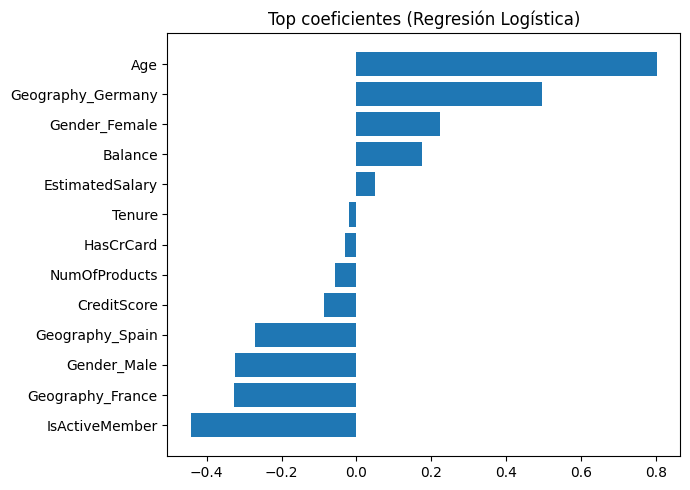

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plot_df = top_lr.sort_values('coef')
plt.barh(plot_df['feature'], plot_df['coef'])
plt.title('Top coeficientes (Regresión Logística)')
plt.tight_layout()
plt.show()

## 4) Avance 2 – Gradient Boosting
- Mejor performance (suele capturar no linealidades)
- Menos interpretable

In [44]:
from sklearn.ensemble import GradientBoostingClassifier

gb = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', GradientBoostingClassifier(random_state=42))
])

gb.fit(X_train, y_train)
metrics_gb, proba_gb, pred_gb = eval_pipe(gb, X_test, y_test)
metrics_gb

{'roc_auc': 0.8702176753024209,
 'accuracy': 0.869,
 'precision': 0.7821011673151751,
 'recall': 0.49385749385749383,
 'f1': 0.6054216867469879,
 'threshold': 0.5}

### Feature importance (aproximada)
Usaremos **permutation importance** (mide cuánto cae el score cuando se permuta una feature).


In [45]:
from sklearn.inspection import permutation_importance

X_test_transformed = gb.named_steps['preprocess'].transform(X_test)
model_gb = gb.named_steps['model']

perm = permutation_importance(model_gb, X_test_transformed, y_test, n_repeats=10, random_state=42, scoring='roc_auc')
perm_df = pd.DataFrame({'feature': feature_names, 'importance_mean': perm.importances_mean})

top_gb = perm_df.sort_values('importance_mean', ascending=False).head(15)
top_gb

,feature,importance_mean
1,Age,0.123953
4,NumOfProducts,0.114945
6,IsActiveMember,0.033903
3,Balance,0.026706
9,Geography_Germany,0.015487
11,Gender_Female,0.003921
0,CreditScore,0.002684
12,Gender_Male,0.001644
10,Geography_Spain,0.000000
5,HasCrCard,-0.000053


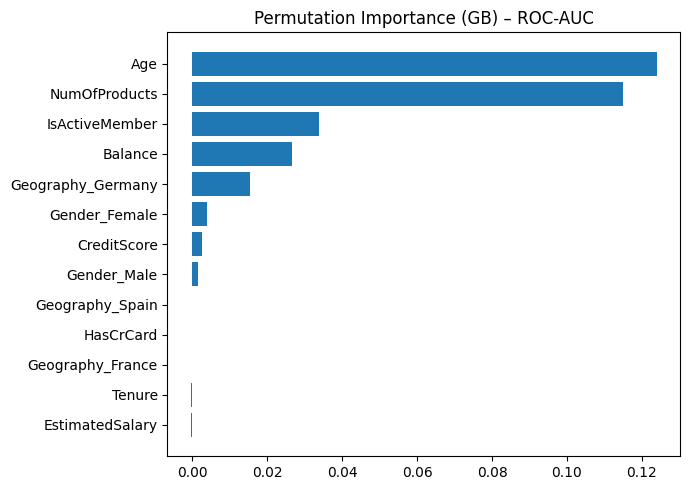

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plot_df = top_gb.sort_values('importance_mean')
plt.barh(plot_df['feature'], plot_df['importance_mean'])
plt.title('Permutation Importance (GB) – ROC-AUC')
plt.tight_layout()
plt.show()

## 5) Avance 3 – Aprendizaje **No supervisado** (segmentación)
La idea NO es predecir churn, sino **entender perfiles/patrones** que sirvan para diseñar y direccionar acciones concretas.

> # **Nota:** en datasets tabulares con one-hot, el clustering completo puede ser costoso. Se sugiere usar PCA/SVD o empezar por variables numéricas.

In [47]:
# 🧩 Segmentación simple (numéricas) + k-means
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

num_only = df.drop(columns=[TARGET] + DROP_COLS + ['Geography','Gender'])
Xn = StandardScaler().fit_transform(num_only)

k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(Xn)

df_seg = df.copy()
df_seg['cluster'] = clusters

cluster_summary = df_seg.groupby('cluster').agg(
    n_clients=('CustomerId','count'),
    churn_rate=('Exited','mean'),
    avg_age=('Age','mean'),
    avg_balance=('Balance','mean'),
    avg_products=('NumOfProducts','mean'),
    active_rate=('IsActiveMember','mean'),
).reset_index()

cluster_summary

,cluster,n_clients,churn_rate,avg_age,avg_balance,avg_products,active_rate
0,0,2940,0.206803,39.110204,78053.305898,1.523129,0.524490
1,1,4089,0.224994,38.967229,122850.085314,1.292492,0.510149
2,2,2971,0.171323,38.672837,11123.586230,1.864355,0.512622


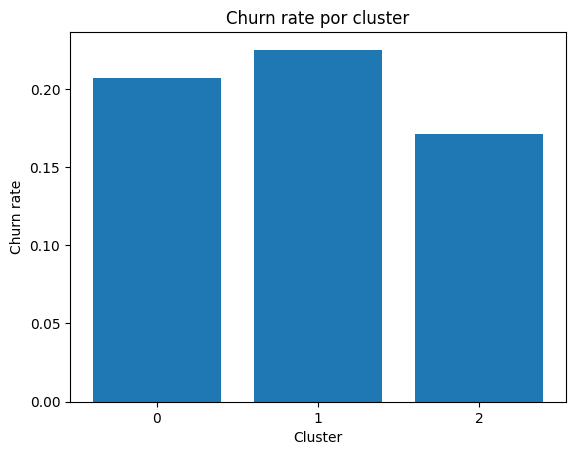

In [48]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(cluster_summary['cluster'].astype(str), cluster_summary['churn_rate'])
plt.title('Churn rate por cluster')
plt.xlabel('Cluster')
plt.ylabel('Churn rate')
plt.show()

## 6) Comparación global y conclusiones
En este avance se pide integrar:
- performance supervisado
- interpretabilidad
- valor estratégico del no supervisado

In [49]:
compare = pd.DataFrame([
    {'modelo':'Regresión Logística', **metrics_lr},
    {'modelo':'Gradient Boosting', **metrics_gb},
]).sort_values('roc_auc', ascending=False)
compare

,modelo,roc_auc,accuracy,precision,recall,f1,threshold
1,Gradient Boosting,0.870218,0.8690,0.782101,0.493857,0.605422,0.5
0,Regresión Logística,0.777165,0.7135,0.387228,0.700246,0.498688,0.5


## 7) Generación del PDF (Reporte_Modelos.pdf)
Este bloque crea un reporte PDF con:
- tabla comparativa
- gráficos (ROC, matrices de confusión, importancias)
- insights y recomendaciones

Artefactos OK: financeguard_artifacts\roc_curves.png financeguard_artifacts\cm_lr.png financeguard_artifacts\cm_gb.png


<Figure size 640x480 with 0 Axes>

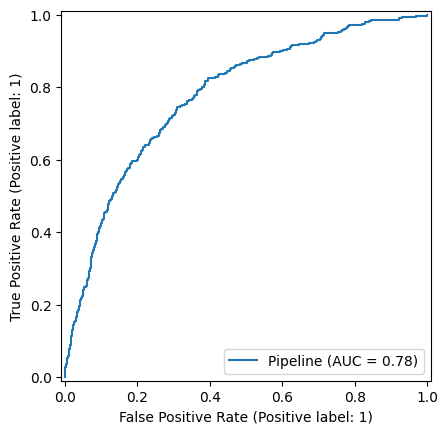

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [50]:
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

out_dir = Path('financeguard_artifacts')
out_dir.mkdir(exist_ok=True)

# ROC
plt.figure()
RocCurveDisplay.from_estimator(log_reg, X_test, y_test)
RocCurveDisplay.from_estimator(gb, X_test, y_test)
plt.title('ROC Curves – Logística vs GB')
roc_path = out_dir / 'roc_curves.png'
plt.savefig(roc_path, bbox_inches='tight', dpi=180)
plt.close()

# Confusion matrices
plt.figure(); ConfusionMatrixDisplay.from_predictions(y_test, pred_lr); plt.title('CM – Logística (thr=0.5)');
cm_lr_path = out_dir / 'cm_lr.png'; plt.savefig(cm_lr_path, bbox_inches='tight', dpi=180); plt.close()

plt.figure(); ConfusionMatrixDisplay.from_predictions(y_test, pred_gb); plt.title('CM – GB (thr=0.5)');
cm_gb_path = out_dir / 'cm_gb.png'; plt.savefig(cm_gb_path, bbox_inches='tight', dpi=180); plt.close()

# Plots de coeficientes e importancias
plt.figure(figsize=(7,5))
plot_df = top_lr.sort_values('coef')
plt.barh(plot_df['feature'], plot_df['coef'])
plt.title('Top coeficientes (Logística)')
plt.tight_layout()
lr_coef_path = out_dir / 'lr_top_coeffs.png'
plt.savefig(lr_coef_path, bbox_inches='tight', dpi=180)
plt.close()

plt.figure(figsize=(7,5))
plot_df = top_gb.sort_values('importance_mean')
plt.barh(plot_df['feature'], plot_df['importance_mean'])
plt.title('Permutation Importance (GB)')
plt.tight_layout()
gb_imp_path = out_dir / 'gb_perm_importance.png'
plt.savefig(gb_imp_path, bbox_inches='tight', dpi=180)
plt.close()

print('Artefactos OK:', roc_path, cm_lr_path, cm_gb_path)

In [51]:
from reportlab.lib.pagesizes import letter
from reportlab.platypus import (
    SimpleDocTemplate,
    Paragraph,
    Spacer,
    Image as RLImage,
    Table,
    TableStyle,
    PageBreak
)
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.lib import colors
from reportlab.lib.units import inch


In [52]:
# 📄 Armado del PDF con reportlab
from reportlab.lib.pagesizes import letter
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Image as RLImage, Table, TableStyle, PageBreak
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.lib import colors
from reportlab.lib.units import inch

styles = getSampleStyleSheet()
styleH = styles['Heading1']
styleH2 = styles['Heading2']
styleN = styles['BodyText']

pdf_path = Path('Reporte_Modelos.pdf')
doc = SimpleDocTemplate(str(pdf_path), pagesize=letter, rightMargin=36, leftMargin=36, topMargin=36, bottomMargin=36)

story = []
story.append(Paragraph('FinanceGuard – Reporte Técnico Final (Avance Nº 4)', styleH))
story.append(Paragraph('Consolidación de modelos de churn + recomendaciones de negocio.', styleN))
story.append(Spacer(1, 12))

# Supuesto de negocio para optimización de threshold/costos
COST_FP = 1
COST_FN = 5  # perder un cliente cuesta 5x más que contactarlo

story.append(Paragraph("Supuesto de negocio (para threshold y métricas de costo)", styleH2))
story.append(Paragraph(
    f"Para la toma de decisiones se adopta el siguiente supuesto explícito:<br/><br/>"
    f"• <b>Costo de Falso Negativo (FN)</b> = {COST_FN} (perder un cliente que iba a abandonar).<br/>"
    f"• <b>Costo de Falso Positivo (FP)</b> = {COST_FP} (contactar/ofrecer incentivo a un cliente que no iba a abandonar).<br/><br/>"
    f"Interpretación: <b>perder un cliente es {COST_FN} veces más costoso</b> que contactarlo innecesariamente. "
    f"Por eso, al optimizar el punto de corte se prioriza <b>Recall</b> (detectar churn) aceptando más falsos positivos.",
    styleN
))
story.append(Spacer(1, 12))


# Tabla de métricas
metrics_table = [
    ['Modelo','ROC-AUC','Accuracy','Precision','Recall','F1','Threshold'],
    ['Regresión Logística', f"{metrics_lr['roc_auc']:.3f}", f"{metrics_lr['accuracy']:.3f}", f"{metrics_lr['precision']:.3f}", f"{metrics_lr['recall']:.3f}", f"{metrics_lr['f1']:.3f}", f"{metrics_lr['threshold']:.2f}"],
    ['Gradient Boosting', f"{metrics_gb['roc_auc']:.3f}", f"{metrics_gb['accuracy']:.3f}", f"{metrics_gb['precision']:.3f}", f"{metrics_gb['recall']:.3f}", f"{metrics_gb['f1']:.3f}", f"{metrics_gb['threshold']:.2f}"],
]

tbl = Table(metrics_table, hAlign='LEFT')
tbl.setStyle(TableStyle([
    ('BACKGROUND', (0,0), (-1,0), colors.lightgrey),
    ('GRID', (0,0), (-1,-1), 0.5, colors.grey),
    ('FONTNAME', (0,0), (-1,0), 'Helvetica-Bold'),
    ('ALIGN', (1,1), (-1,-1), 'CENTER'),
]))

story.append(Paragraph('Resumen de performance (test set):', styleH2))
story.append(Spacer(1, 6))
story.append(tbl)
story.append(Spacer(1, 12))

# Visualizaciones
story.append(RLImage(str(roc_path), width=6.5*inch, height=4.2*inch))
story.append(PageBreak())
story.append(RLImage(str(lr_coef_path), width=6.5*inch, height=4.2*inch))
story.append(Spacer(1, 10))
story.append(RLImage(str(gb_imp_path), width=6.5*inch, height=4.2*inch))
story.append(PageBreak())
story.append(RLImage(str(cm_lr_path), width=6.5*inch, height=4.2*inch))
story.append(Spacer(1, 10))
story.append(RLImage(str(cm_gb_path), width=6.5*inch, height=4.2*inch))

# Insights
story.append(PageBreak())
story.append(Paragraph('Insights y recomendaciones', styleH2))
story.append(Paragraph('• Usar Gradient Boosting como motor de scoring y Logística para explicabilidad (drivers).<br/>• Enfocar acciones en clientes con baja vinculación (pocos productos), inactividad y perfiles asociados a churn.<br/>• Optimizar el umbral según costos de negocio (ver 4_Extra_credit.ipynb).', styleN))

doc.build(story)

print('PDF generado:', pdf_path.resolve())

PDF generado: C:\Users\vanin\OneDrive\Documentos\SoyHenry\Data_Science\Proyectos\M4_Machine_Learning\ProyectoM4_VaninaCavallin\Notebooks\Reporte_Modelos.pdf


# Explicación del informe:

Portada:
- FinanceGuard – Reporte Técnico Final (Avance Nº 4)
- Consolidación de modelos de churn + recomendaciones de negocio


*En este informe no entreno modelos nuevos, sino que junto todo lo aprendido en los avances anteriores para decidir qué modelo usar, cómo usarlo y para qué.*

a) Supuesto de negocio
¿Qué muestra técnicamente?

- Costo FN = 5 → perder un cliente que iba a abandonar
- Costo FP = 1 → contactar a alguien que no iba a abandonar

Y se aclara que *perder un cliente* es 5 veces más costoso que *contactarlo innecesariamente*.

**Esto define el criterio de decisión del proyecto. No todos los errores valen lo mismo. Para el banco, perder un cliente es mucho más grave que molestarlo con una oferta que no necesitaba.**

### Insight clave
1. Priorizamos **Recall**.
2. Aceptamos más falsos positivos.
3. El threshold no se optimiza solo por accuracy-

b) Tabla de métricas (comparación de modelos)

Modelo	            ROC-AUC	        Accuracy	    Precision	       Recall	     F1
Logística	          0.777	           0.714	        0.387	        0.700	     0.499
Gradient Boosting	  0.870	           0.869	        0.782	        0.494	     0.605

Gradient Boosting es claramente superior en ROC-AUC, Accuracy, Precision, F1.
Logística es superior en Recall.

**Gradient Boosting predice mejor en general, pero la Regresión Logística detecta más clientes que realmente se van.**

### Insight clave
1. GB = mejor ranking y scoring
2. Logística = mejor sensibilidad al churn
3. No hay un “mejor absoluto”: depende del objetivo

c) Curva ROC (Logística vs Gradient Boosting)
¿Qué muestra técnicamente?

- La curva ROC mide la capacidad del modelo de separar churn vs no churn para todos los thresholds posibles.
- El área bajo la curva (AUC): Logística ≈ 0.78
- Gradient Boosting ≈ 0.87

**La curva ROC me dice qué tan bien el modelo ordena a los clientes desde los más riesgosos a los menos riesgosos.**

### Insight clave
- Gradient Boosting: ordena mejor y es ideal para priorizar campañas (top clientes en riesgo).

d) Coeficientes de la Regresión Logística

¿Qué muestra técnicamente?

Variables con impacto directo sobre el churn

Signo:
- positivo → aumenta churn
- negativo → reduce churn

Ejemplos visibles:
- Edad ↑ → más churn
- IsActiveMember ↓ → menos churn
- Alemania ↑ → más churn

**Este gráfico me dice por qué un cliente se va.**

### Insight clave
Este modelo es ideal para:
- explicaciones.
- storytelling.
- justificar decisiones ante negocio.

e) Permutation Importance (Gradient Boosting)

¿Qué muestra técnicamente? Muestra cuánto empeora el modelo si una variable se desordena.

Las variables más importantes:
- Edad
- Número de productos
- Actividad
- Balance

**Estas son las variables que el modelo realmente usa para decidir.**

### Insight clave
Coincide con la logística (consistencia) y refuerza la idea de:
- baja vinculación.
- inactividad.
- perfiles de riesgo claros.

e)  Matrices de confusión
- Logística (thr = 0.5) = 
    - Detecta muchos churn (alto recall). 
    - Muchos falsos positivos.
- Gradient Boosting (thr = 0.5)=
    - Muy pocos falsos positivos
    - Se le escapan más churn reales

**La logística es más ‘paranoica’: marca a muchos como churn.**
**Gradient Boosting es más ‘preciso’, pero se le escapan algunos que sí se van.**

### Insight clave

👉 *Extra Credit:*
1. Ajustar el threshold según costo
2. No quedarse con 0.5 por default

f) Recomendaciones finales:

**Uso el modelo potente para decidir a quién llamar, y el modelo interpretable para saber qué decirle.**


> ## Conclusión integradora: en este proyecto no existe un único modelo óptimo. Gradient Boosting ofrece el mejor desempeño predictivo y es ideal como motor de scoring para priorizar clientes en riesgo, mientras que la Regresión Logística aporta interpretabilidad y permite entender los drivers del churn. Dado que perder un cliente es cinco veces más costoso que contactarlo innecesariamente, el foco está puesto en maximizar la detección de churn, incluso a costa de más falsos positivos. La combinación de ambos enfoques, junto con una optimización del threshold basada en costos de negocio, permite una estrategia de retención más efectiva y alineada con los objetivos del banco.